<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 109.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 143.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 126.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 139.4 MB/s eta 0:00:00


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


--2026-04-16 04:24:35--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  42.8MB/s    in 3.5s    

2026-04-16 04:24:38 (43.4 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


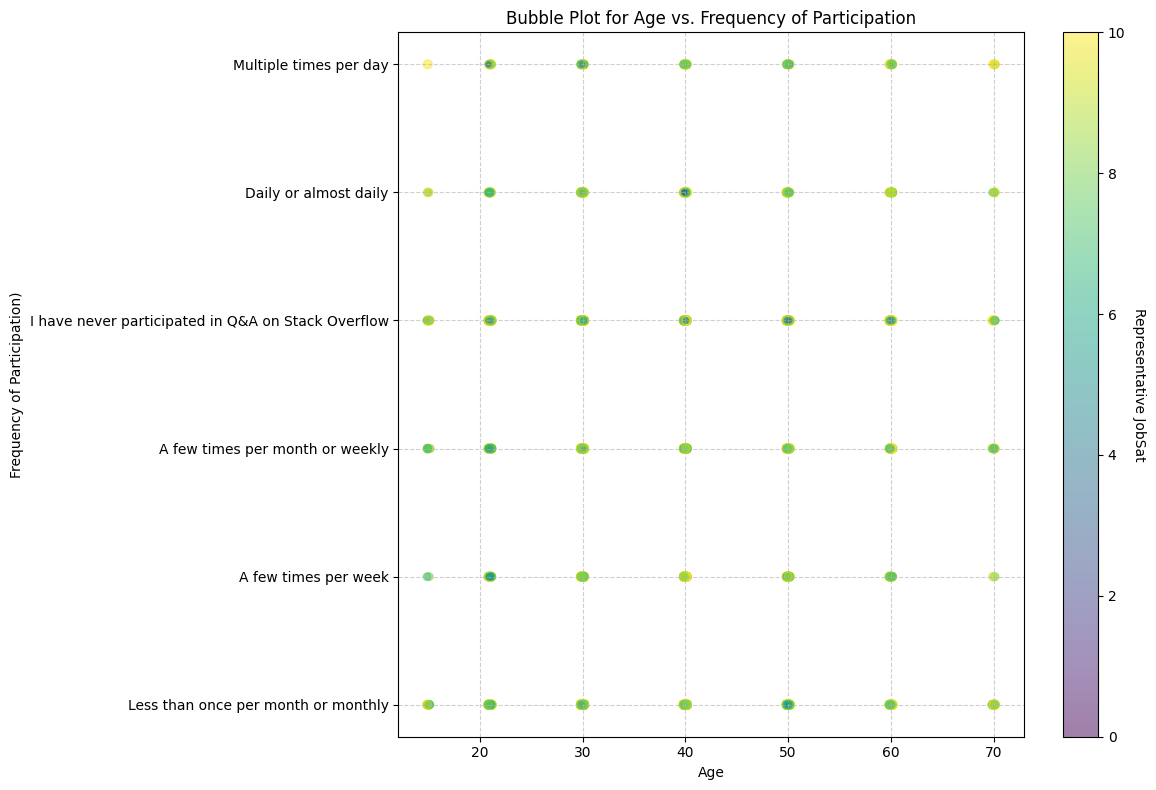

In [21]:
##Write your code here
import numpy as np
df_clean = df.dropna(subset=['SOPartFreq', 'JobSat', 'Age'])

#Numeric representatives for each range
age_map = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df_clean['Age_Numeric'] = df_clean['Age'].map(age_map)

# Create the Bubble Plot
plt.figure(figsize=(12, 8))

# Adding a small amount of jitter to JobSatPoints_6 helps visualize density
# since satisfaction scores are usually discrete integers
x_jittered = df_clean['Age_Numeric'] + np.random.uniform(-0.15, 0.15, size=len(df_clean))

scatter = plt.scatter(
    x=x_jittered, 
    y=df_clean['SOPartFreq'],
    s=df_clean['JobSat'] * 4,  # Adjust size multiplier for visibility
    alpha=0.5,
    c=df_clean['JobSat'],     # Color points by age as well
)

# Formatting and Labels
plt.title('Bubble Plot for Age vs. Frequency of Participation')
plt.xlabel('Age')
plt.ylabel('Frequency of Participation)')

# Colorbar to indicate what colors correspond to which JobSat
cbar = plt.colorbar(scatter)
cbar.set_label('Representative JobSat', rotation=270, labelpad=15)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


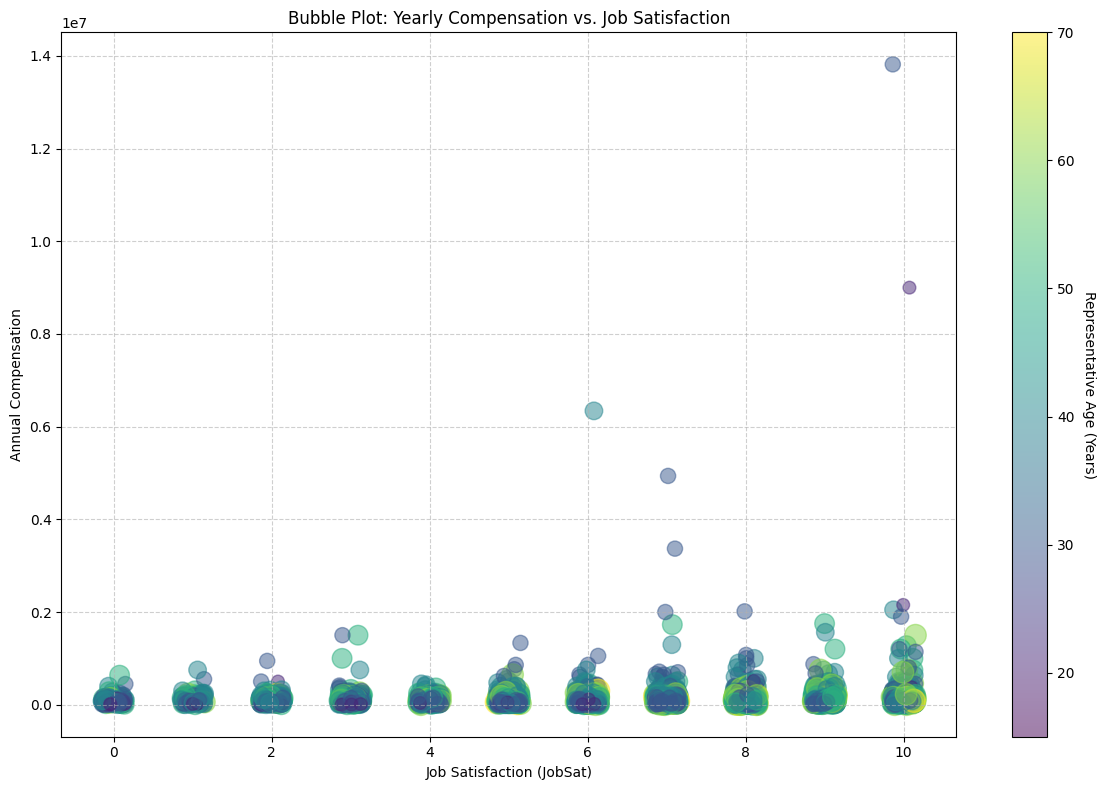

In [5]:
##Write your code here
df_clean = df.dropna(subset=['ConvertedCompYearly', 'JobSat', 'Age'])

#Numeric representatives for each range
age_map = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df_clean['Age_Numeric'] = df_clean['Age'].map(age_map)

# Create the Bubble Plot
plt.figure(figsize=(12, 8))

# Adding a small amount of jitter to JobSat helps visualize density
# since satisfaction scores are usually discrete integers
x_jittered = df_clean['JobSat'] + np.random.uniform(-0.15, 0.15, size=len(df_clean))

scatter = plt.scatter(
    x=x_jittered, 
    y=df_clean['ConvertedCompYearly'],
    s=df_clean['Age_Numeric'] * 4,  # Adjust size multiplier for visibility
    alpha=0.5,
    c=df_clean['Age_Numeric'],     # Color points by age as well
)

# Formatting and Labels
plt.title('Bubble Plot: Yearly Compensation vs. Job Satisfaction')
plt.xlabel('Job Satisfaction (JobSat)')
plt.ylabel('Annual Compensation')

# Colorbar to indicate what colors correspond to which ages
cbar = plt.colorbar(scatter)
cbar.set_label('Representative Age (Years)', rotation=270, labelpad=15)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



Note: you may need to restart the kernel to use updated packages.


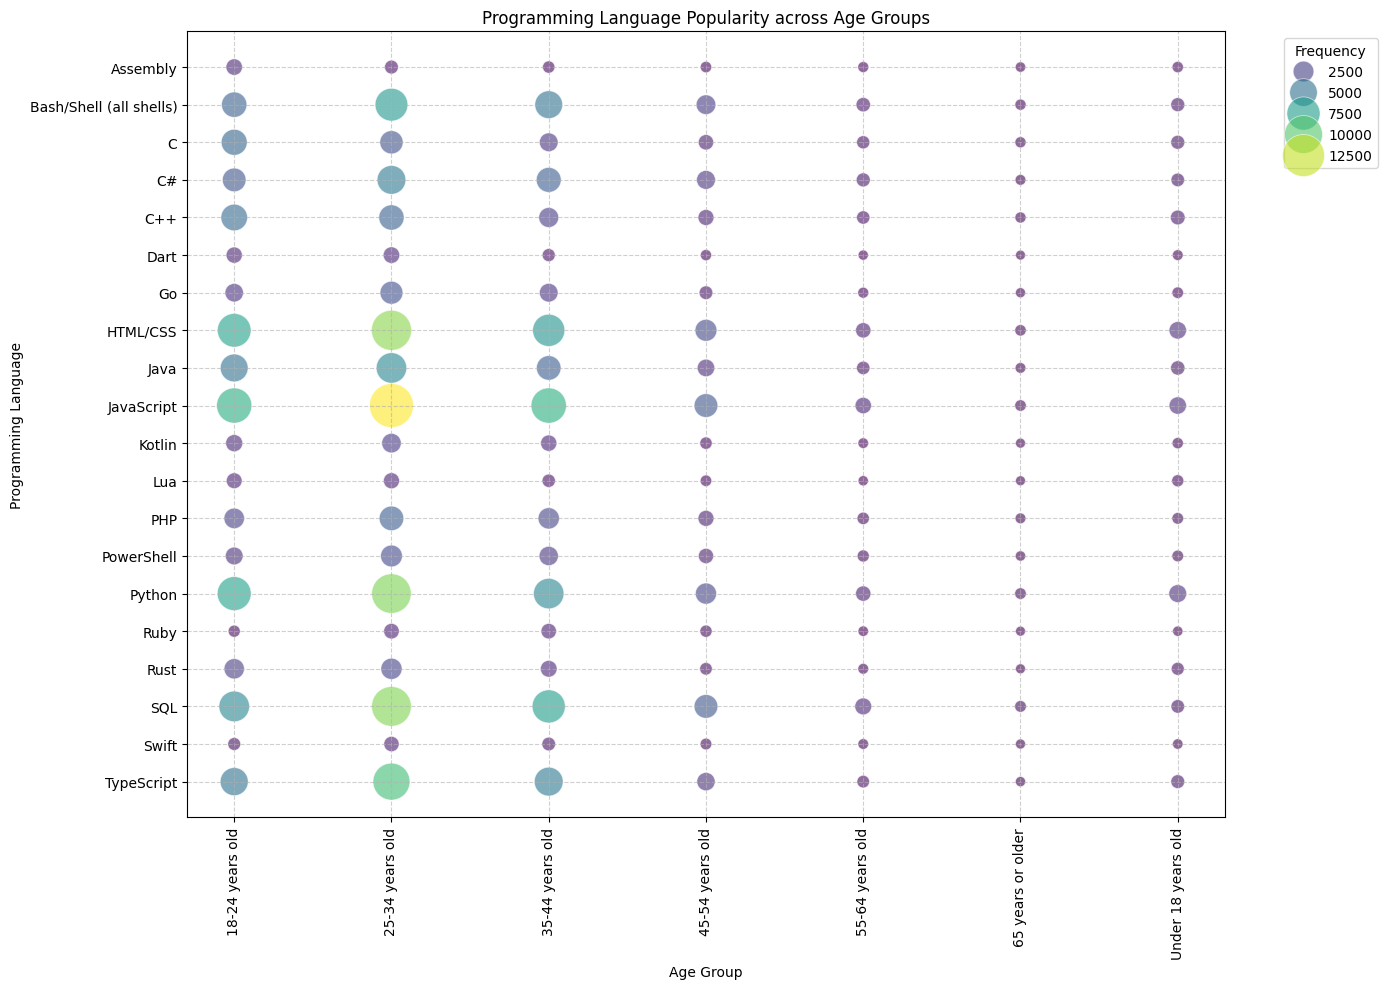

In [6]:
##Write your code here
%pip install seaborn
import seaborn as sns

# Drop rows where Age or LanguageHaveWorkedWith is missing
df_clean = df.dropna(subset=['Age', 'LanguageHaveWorkedWith'])

# Split the semicolon-separated languages and explode the dataframe
df_exploded = df_clean.assign(Language=df_clean['LanguageHaveWorkedWith'].str.split(';')).explode('Language')

# Define Age order for the x-axis
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

# Filtering for valid age categories (excluding 'Prefer not to say')
df_exploded = df_exploded[df_exploded['Age'].isin(age_order)]

#Top 20 languages to keep the chart legible
top_languages = df_exploded['Language'].value_counts().nlargest(20).index
df_subset = df_exploded[df_exploded['Language'].isin(top_languages)]

# Group by Age and Language to calculate frequency
bubble_data = df_subset.groupby(['Age', 'Language']).size().reset_index(name='Frequency')

# Create the Bubble Plot
plt.figure(figsize=(14, 10))
scatter = sns.scatterplot(
    data=bubble_data,
    x='Age',
    y='Language',
    size='Frequency',
    hue='Frequency',
    sizes=(50, 1000), # Range of bubble sizes
    palette='viridis',
    alpha=0.6,
    legend='brief'
)

# Customization
plt.title('Programming Language Popularity across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Programming Language')
plt.xticks(rotation=90)
plt.legend(title='Frequency', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


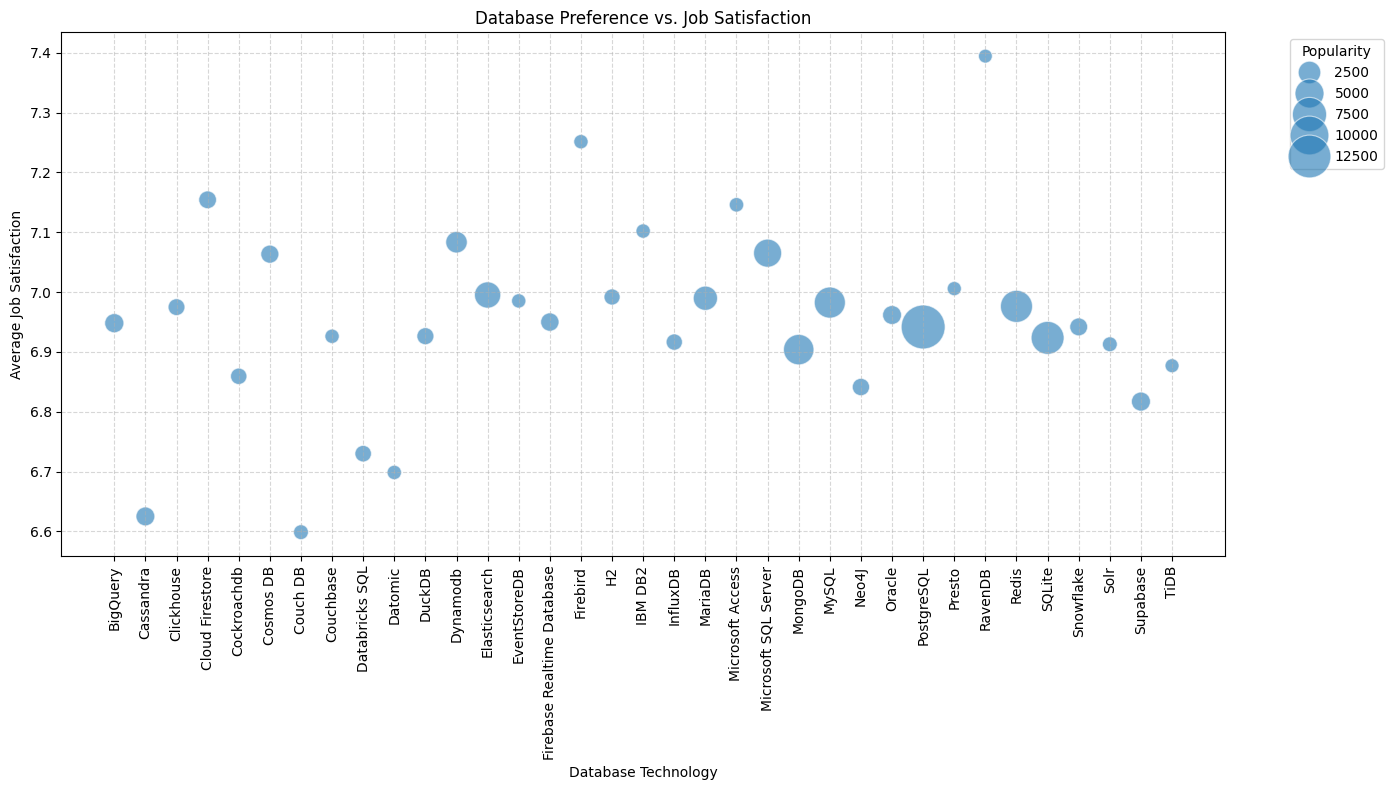

In [7]:

df_clean = df.dropna(subset=['DatabaseWantToWorkWith', 'JobSat'])

# Split the semicolon-separated string and explode into individual rows
df_db = df_clean.assign(Database=df_clean['DatabaseWantToWorkWith'].str.split(';')).explode('Database')

#  Calculate Popularity and Average Satisfaction
db_stats = df_db.groupby('Database').agg(
    Popularity=('Database', 'count'),
    AvgSatisfaction=('JobSat', 'mean')
).reset_index()

# Create the Bubble Plot
plt.figure(figsize=(14, 8))

# Using scatterplot where 'size' corresponds to Popularity
scatter = sns.scatterplot(
    data=db_stats, 
    x='Database', 
    y='AvgSatisfaction', 
    size='Popularity', 
    sizes=(100, 1000), # Range of bubble sizes
    alpha=0.6, 
  
)

# Formatting
plt.title('Database Preference vs. Job Satisfaction')
plt.xlabel('Database Technology')
plt.ylabel('Average Job Satisfaction')
plt.xticks(rotation=90) # Rotate for better label readability
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Popularity')
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


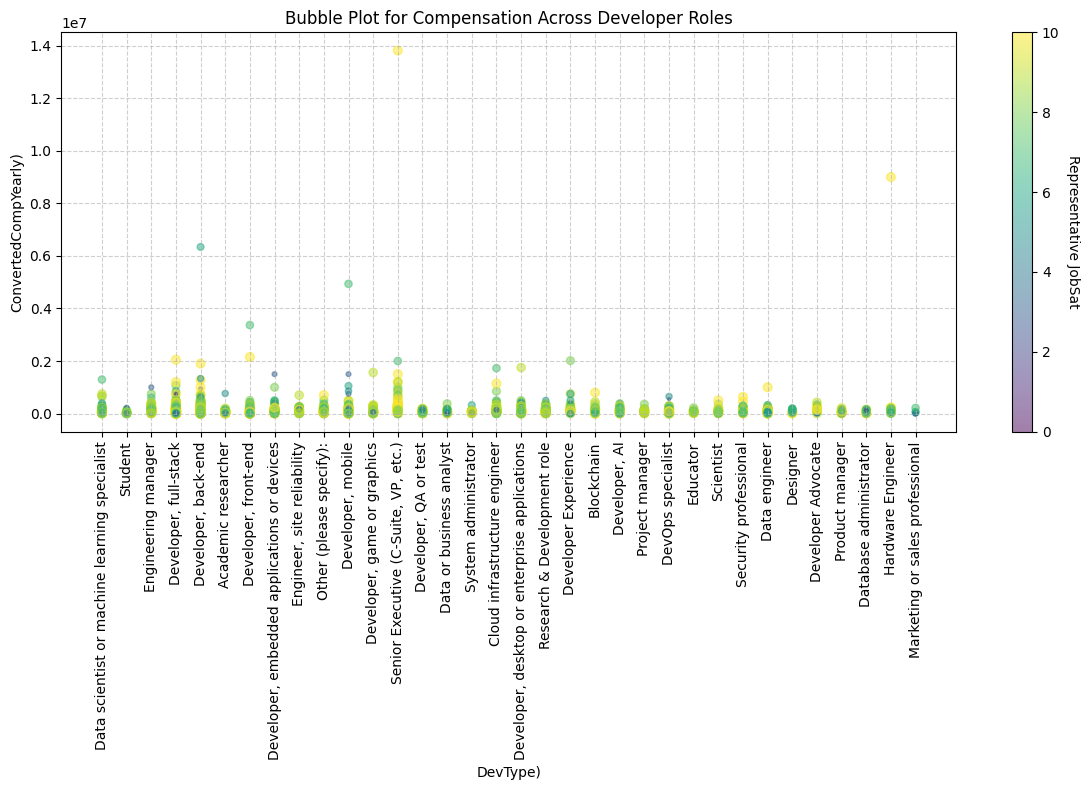

In [8]:
##Write your code here

df_clean = df.dropna(subset=['ConvertedCompYearly', 'JobSat', 'DevType'])

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    x=df_clean['DevType'],
    y=df_clean['ConvertedCompYearly'],
    s=df_clean['JobSat'] * 4,  # Adjust size multiplier for visibility
    alpha=0.5,
    c=df_clean['JobSat'],     # Color points by age as well
)

# Formatting and Labels
plt.title('Bubble Plot for Compensation Across Developer Roles')
plt.xlabel('DevType)')
plt.ylabel('ConvertedCompYearly)')
plt.xticks(rotation=90)

# Colorbar to indicate what colors correspond to which JobSat
cbar = plt.colorbar(scatter)
cbar.set_label('Representative JobSat', rotation=270, labelpad=15)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


In [10]:
df['NEWCollabToolsHaveWorkedWith'].unique()

<StringArray>
[                                                                                                                      nan,
                                                                                     'PyCharm;Visual Studio Code;WebStorm',
                                                                                                           'Visual Studio',
                                                                                                                     'Vim',
                                                                                       'Nano;Vim;Visual Studio Code;Xcode',
                                                                                                                 'RStudio',
                                                                                                      'Visual Studio Code',
                  'Android Studio;IntelliJ IDEA;Netbeans;Notepad++;Sublime Text;Visual Studio;Visual Studio Code;WebSt

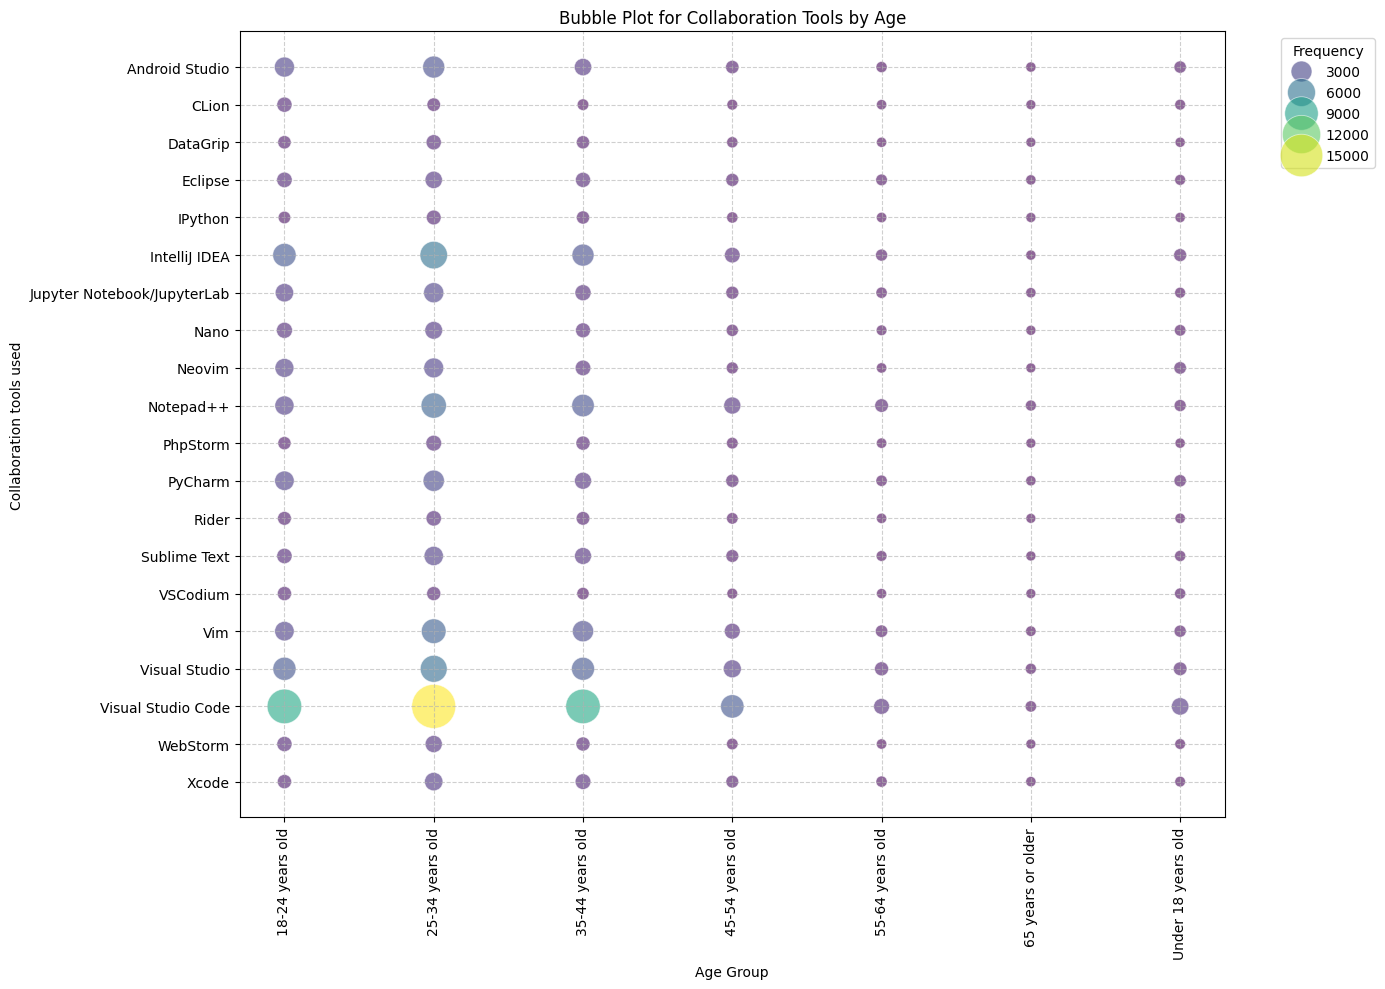

In [12]:
##Write your code here
##Write your code here

# Drop rows where Age or NEWCollabToolsHaveWorkedWith is missing
df_clean = df.dropna(subset=['Age', 'NEWCollabToolsHaveWorkedWith'])

# Split the semicolon-separated Tools and explode the dataframe
df_exploded = df_clean.assign(Tools=df_clean['NEWCollabToolsHaveWorkedWith'].str.split(';')).explode('Tools')

# Define Age order for the x-axis
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

# Filtering for valid age categories (excluding 'Prefer not to say')
df_exploded = df_exploded[df_exploded['Age'].isin(age_order)]

#Top 20 Tools to keep the chart legible
top_tools = df_exploded['Tools'].value_counts().nlargest(20).index
df_subset = df_exploded[df_exploded['Tools'].isin(top_tools)]

# Group by Age and Tools to calculate frequency
bubble_data = df_subset.groupby(['Age', 'Tools']).size().reset_index(name='Frequency')

# Create the Bubble Plot
plt.figure(figsize=(14, 10))
scatter = sns.scatterplot(
    data=bubble_data,
    x='Age',
    y='Tools',
    size='Frequency',
    hue='Frequency',
    sizes=(50, 1000), # Range of bubble sizes
    palette='viridis',
    alpha=0.6,
    legend='brief'
)

# Customization
plt.title('Bubble Plot for Collaboration Tools by Age')
plt.xlabel('Age Group')
plt.ylabel('Collaboration tools used')
plt.xticks(rotation=90)
plt.legend(title='Frequency', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



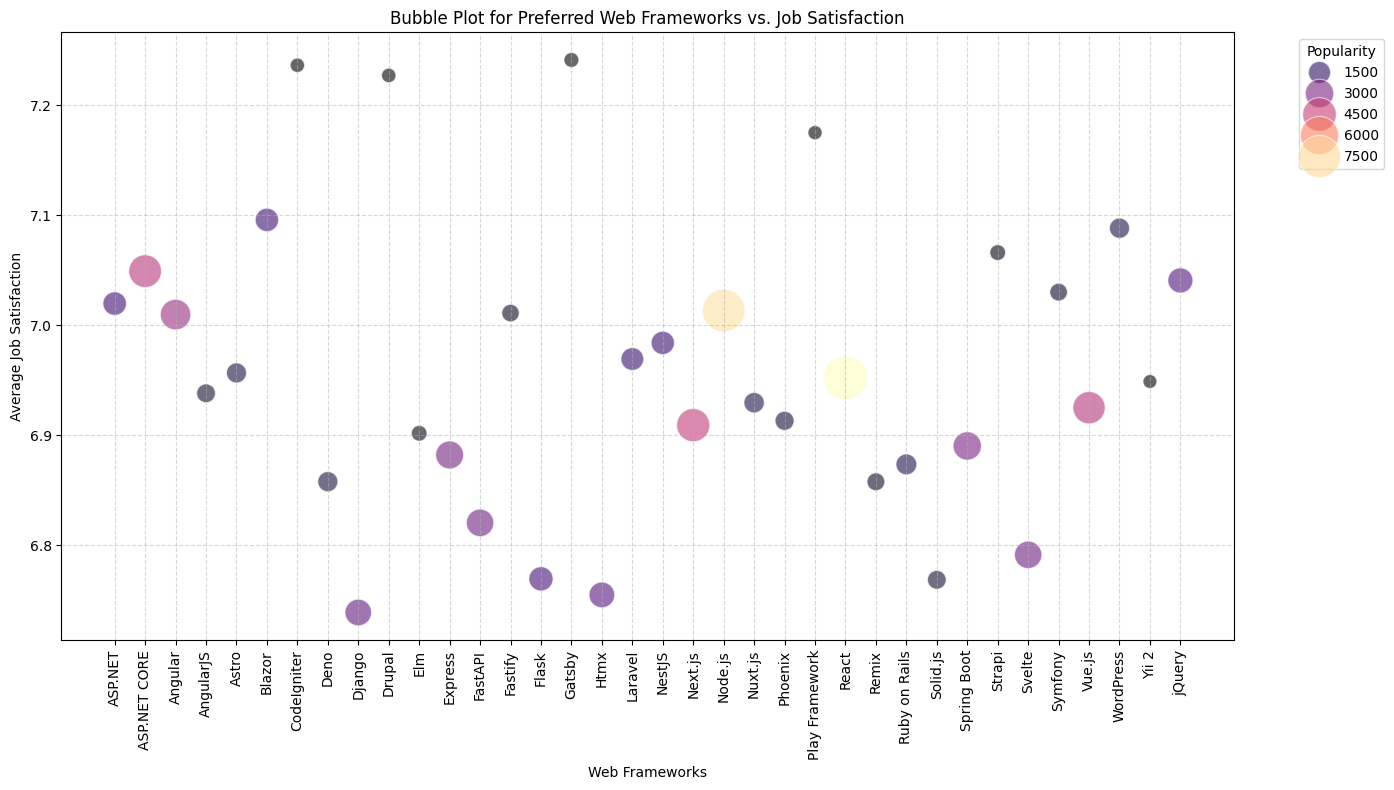

In [17]:
##Write your code here


df_clean = df.dropna(subset=['WebframeWantToWorkWith', 'JobSat'])

# Split the semicolon-separated string and explode into individual rows
df_db = df_clean.assign(Webframe=df_clean['WebframeWantToWorkWith'].str.split(';')).explode('Webframe')

#  Calculate Popularity and Average Satisfaction
db_stats = df_db.groupby('Webframe').agg(
    Popularity=('Webframe', 'count'),
    AvgSatisfaction=('JobSat', 'mean')
).reset_index()

# Create the Bubble Plot
plt.figure(figsize=(14, 8))

# Using scatterplot where 'size' corresponds to Popularity
scatter = sns.scatterplot(
    data=db_stats, 
    x='Webframe', 
    y='AvgSatisfaction', 
    size='Popularity', 
    hue='Popularity',
    sizes=(100, 1000), # Range of bubble sizes
    palette='magma',
    alpha=0.6, 
  
)

# Formatting
plt.title('Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction')
plt.xlabel('Web Frameworks')
plt.ylabel('Average Job Satisfaction')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Popularity')
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



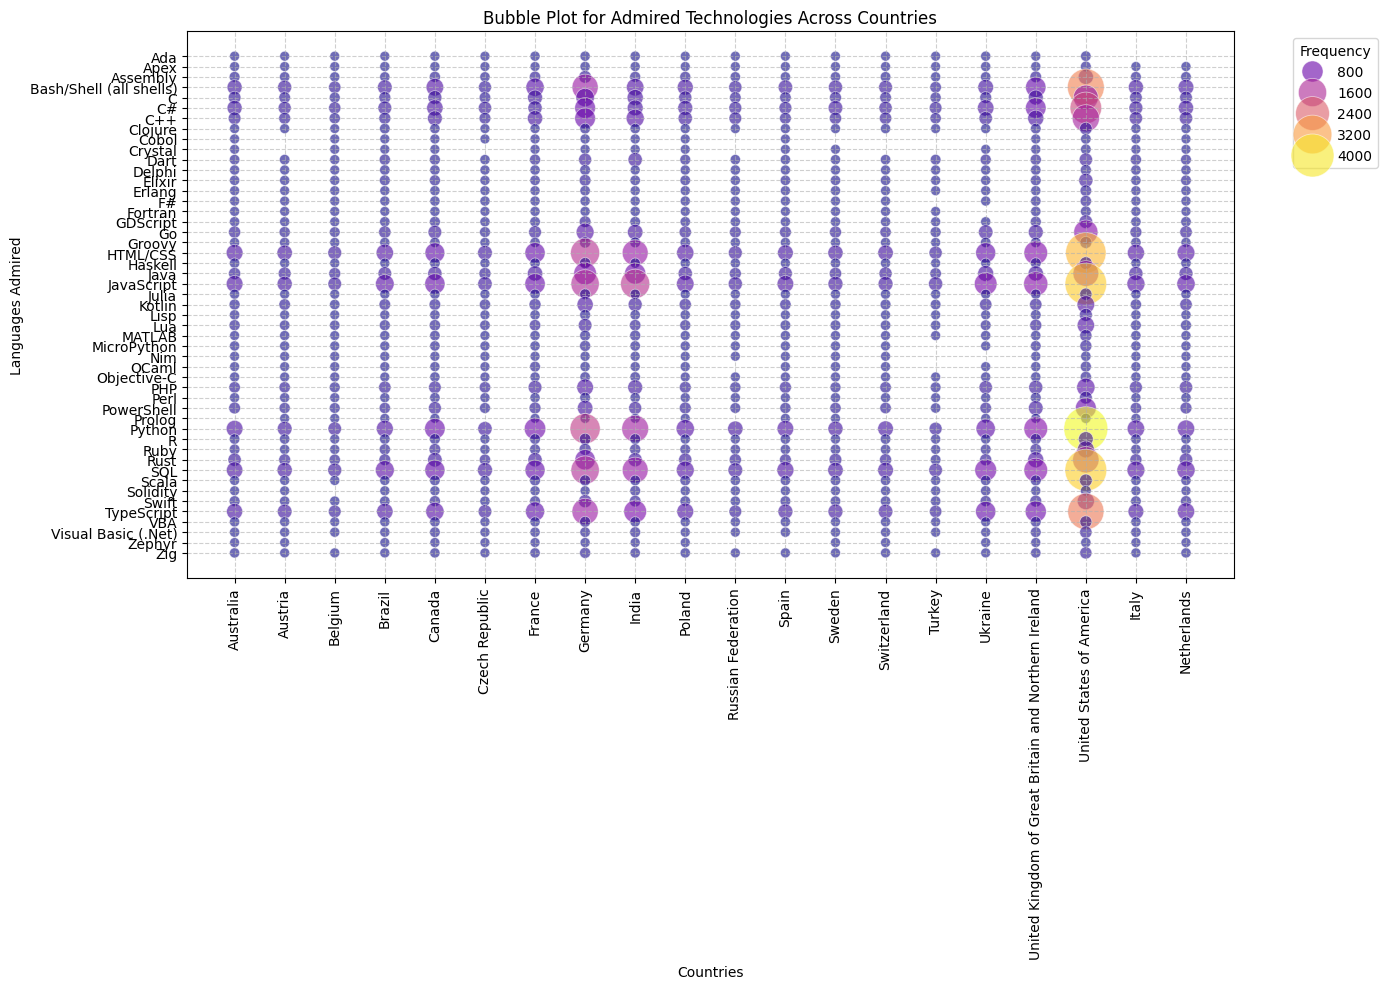

In [22]:
##Write your code here
df_clean = df.dropna(subset=['LanguageAdmired', 'Country'])

# Split the semicolon-separated string and explode into individual rows
df_db = df_clean.assign(LangAdmired=df_clean['LanguageAdmired'].str.split(';')).explode('LangAdmired')

top_LangAdmired = df_db['LangAdmired'].value_counts().nlargest(20).index
df_subset = df_db[df_db['LangAdmired'].isin(top_LangAdmired)]

top_countries = df_db['Country'].value_counts().nlargest(20).index
df_subset = df_db[df_db['Country'].isin(top_countries)]


# Group by LangAdmired and Country to calculate frequency
bubble_data = df_subset.groupby(['LangAdmired', 'Country']).size().reset_index(name='Frequency')

# Create the Bubble Plot
plt.figure(figsize=(14, 10))
scatter = sns.scatterplot(
    data=bubble_data,
    x='Country',
    y='LangAdmired',
    size='Frequency',
    hue='Frequency',
    sizes=(50, 1000), # Range of bubble sizes
    palette='plasma',
    alpha=0.6,
    legend='brief'
)

# Customization
plt.title('Bubble Plot for Admired Technologies Across Countries')
plt.xlabel('Countries')
plt.ylabel('Languages Admired')
plt.xticks(rotation=90)
plt.legend(title='Frequency', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
